In [ ]:
!pip install nltk

In [ ]:
#import libraries

import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils import resample

In [ ]:
nltk.download('punkt')
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
#features extraction

url = "https://raw.githubusercontent.com/dD2405/Twitter_Sentiment_Analysis/master/train.csv"
df = pd.read_csv(url)

In [ ]:
df['label'] = df['label'].map({0: 'negative', 1: 'positive'})

In [ ]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#\w+", "", text)
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"[^\w\s]", "", text)
    words = [w for w in text.split() if w not in stop_words]
    return " ".join(words)

df['clean_tweet'] = df['tweet'].apply(clean_text)


In [ ]:
df_majority = df[df.label == "positive"]
df_minority = df[df.label == "negative"]

df_minority_upsampled = resample(df_minority, replace=True, n_samples=len(df_majority), random_state=42)
df_balanced = pd.concat([df_majority, df_minority_upsampled]).sample(frac=1, random_state=42)

# Features
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df_balanced['clean_tweet'])
y = df_balanced['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

Accuracy: 0.7848383500557413
              precision    recall  f1-score   support

    negative       0.80      0.79      0.80       473
    positive       0.77      0.78      0.77       424

    accuracy                           0.78       897
   macro avg       0.78      0.78      0.78       897
weighted avg       0.78      0.78      0.78       897



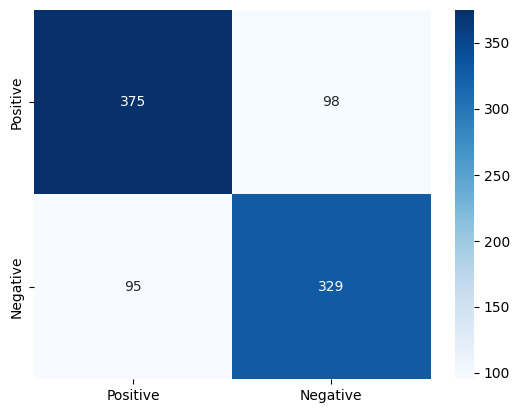

In [ ]:
#model evaluation
predictions = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, predictions))
print(classification_report(y_test, predictions))

cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Positive','Negative'], yticklabels=['Positive','Negative'])
plt.show()

In [ ]:
#sentiment prediction

def predict_sentiment(tweet):
    cleaned = clean_text(tweet)
    vector = vectorizer.transform([cleaned])
    proba = model.predict_proba(vector)[0]
    confidence = max(proba)

    if confidence < 0.51:
        sentiment = "Negative"
    elif confidence > 0.60:
        sentiment = "Positive"
    else:
        sentiment = "Neutral"
    print(f"Tweet: {tweet}\nSentiment: {sentiment}\nConfidence: {confidence}")

# Example
predict_sentiment("I love this internship!")

Tweet: I love this internship!
Sentiment: Positive
Confidence: 0.7492341746609155


('Positive', np.float64(0.7492341746609155))

In [ ]:
df['label'].value_counts()

,count
label,
negative,29720
positive,2242


In [ ]:
from sklearn.utils import resample

# Separate classes
df_majority = df[df.label == "positive"]
df_minority = df[df.label == "negative"]

# Upsample minority
df_minority_upsampled = resample(
    df_minority,
    replace=True,
    n_samples=len(df_majority),
    random_state=42
)

# Combine
df_balanced = pd.concat([df_majority, df_minority_upsampled])

# Shuffle the balanced dataset
df_balanced = df_balanced.sample(frac=1, random_state=42)

# Create features again using balanced data
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df_balanced['clean_tweet'])
y = df_balanced['label']

# Train test split again
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model again
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train, y_train)

# Test accuracy again
predictions = model.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, predictions))
print(classification_report(y_test, predictions))

Accuracy: 0.7848383500557413
              precision    recall  f1-score   support

    negative       0.80      0.79      0.80       473
    positive       0.77      0.78      0.77       424

    accuracy                           0.78       897
   macro avg       0.78      0.78      0.78       897
weighted avg       0.78      0.78      0.78       897



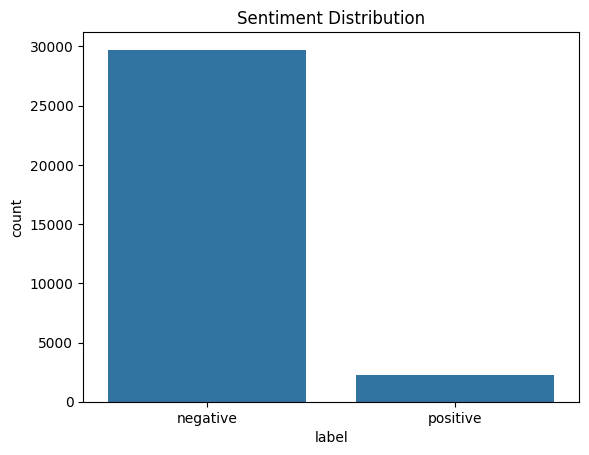

In [ ]:

sns.countplot(x=df['label'])
plt.title("Sentiment Distribution")
plt.show()

In [ ]:
predict_sentiment("this smell is terrible")
predict_sentiment("I love this internship")
predict_sentiment("Worst experience ever")
predict_sentiment("hello")

Tweet: this smell is terrible
Sentiment: Neutral
Confidence: 0.5044290538259358
Tweet: I love this internship
Sentiment: Positive
Confidence: 0.7492341746609155
Tweet: Worst experience ever
Sentiment: Positive
Confidence: 0.7385729092327521
Tweet: hello
Sentiment: Neutral
Confidence: 0.5554008079871187


('Neutral', np.float64(0.5554008079871187))

In [ ]:

user_tweet = input("Enter a tweet: ")

prediction = predict_sentiment(user_tweet)

Enter a tweet: hello
Tweet: hello
Sentiment: Neutral
Confidence: 0.5554008079871187


## Conclusion

In this project, we built a Twitter Sentiment Analysis model using Natural Language Processing techniques.

The tweets were preprocessed and converted into numerical features using TF-IDF Vectorization. A Multinomial Naive Bayes model was trained to classify tweets into sentiment categories.

The model successfully predicts the sentiment of new tweets and can classify them as Positive, Negative, or Neutral based on prediction confidence.

This project demonstrates the practical application of machine learning for text sentiment analysis.